In [51]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal

In [52]:
class qudratic_eq(TypedDict):
    a:int
    b:int 
    c:int
    Equation:str
    discreminent:float
    result:str

In [53]:
def show_eq(state:qudratic_eq):
    equation=f"{state['a']}X2 + {state["b"]}X +{state["c"]}"
    return {"Equation":equation}

def calculate_discreminent(state:qudratic_eq):
    discreminent=state['b']**2 - 4*state["a"]*state['c']
    return {'discreminent':discreminent}

    

In [54]:
import math
def real_root(state:qudratic_eq):

    root1 = (-state['b'] + math.sqrt(state['discreminent'])) / (2*state['a'])
    root2 = (-state['b'] - math.sqrt(state['discreminent'])) / (2*state['a'])
    result=f"the real roots root1-{root1} and the root2-{root2}"
    return {"result":result}


def repeated_root(state:qudratic_eq):
    root1 = (-state['b'])/ (2*state['a'])
    result=f"the only repeated root is -{root1} "
    return {"result":result}

def no_real_root(State:qudratic_eq):
    result=f"no real roots"
    return {"result":result}

In [55]:
def check_condition(state:qudratic_eq)->Literal['real_root','no_real_root','repeated_root']:
    if state['discreminent'] > 0:
        return "real_root"
    elif state['discreminent'] == 0:
        return "reapeated_root"
    else:
        return "no_real_root"
    

In [56]:
graph=StateGraph(qudratic_eq)
graph.add_node('show_eq',show_eq)
graph.add_node('calclute_discreminent',calculate_discreminent)
graph.add_node('real_root', real_root)
graph.add_node('no_real_root', no_real_root)
graph.add_node('repeated_root', repeated_root)

graph.add_edge(START,'show_eq')
graph.add_edge('show_eq','calclute_discreminent')

graph.add_conditional_edges('calclute_discreminent',check_condition)
graph.add_edge('real_root', END)
graph.add_edge('no_real_root', END)
graph.add_edge('repeated_root', END)

workflow=graph.compile()

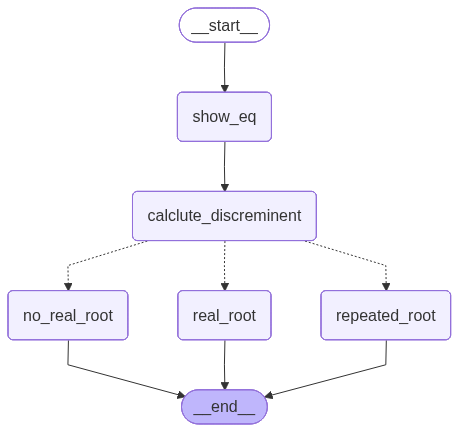

In [57]:
workflow

In [58]:
intial_input={'a':-4,'b':5,'c':6}
workflow.invoke(intial_input)

{'a': -4,
 'b': 5,
 'c': 6,
 'Equation': '-4X2 + 5X +6',
 'discreminent': 121,
 'result': 'the real roots root1--0.75 and the root2-2.0'}